* Pipeline Data :
In this notebook, we will first download the pipeline data from various sources. Then we will try to do a primary analysis of the raw data and clean it for analysing the oil production against it.

In [1]:
import geopandas as gpd
import pandas as pd
import os #to create directories and stuff locally 
import requests #directly lets us access and download data from the internet
import zipfile # once we download stuff, we  use this to unzip files
from pathlib import Path


Now we will download the data. As we go on in the project, we might end up re-downloading things, so we write if statements to make sure we dont end up redownloading stuff. We also make sure, we are not creating a new file with a preexisting name.

Now we will download data in chunks so its easy to accees. Claude suggested this, I have never seen any syntax like this before

In [2]:
import requests
import pandas as pd
from pathlib import Path

EIA_API_KEY ="BjQZbyIfc7E0KsnerX7R8P26BJrnrrHtLZTrCRpv"

# Create save directory
Path("data/raw/waha_price").mkdir(parents=True, exist_ok=True)

# Pull Waha Hub monthly spot price from EIA API
r = requests.get(
    "https://api.eia.gov/v2/natural-gas/pri/spot/data/",
    params={
        "api_key": EIA_API_KEY,
        "frequency": "monthly",
        "data[0]": "value",
        "facets[series][]": "RNGWHHUS3m",
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    },
    timeout=30
)

print("Status:", r.status_code)
print("Response:", r.json())

Status: 400
Response: {'error': 'Requested path /natural-gas/pri/spot is not valid.', 'code': 400}


In [3]:
import requests
import pandas as pd
from pathlib import Path

EIA_API_KEY ="BjQZbyIfc7E0KsnerX7R8P26BJrnrrHtLZTrCRpv"

Path("data/raw/waha_price").mkdir(parents=True, exist_ok=True)

# EIA v1 compatibility endpoint — correct series ID for Waha Hub monthly
url = "https://api.eia.gov/v2/seriesid/NG.RNGWHHUS3M.M"

r = requests.get(url, params={"api_key": EIA_API_KEY}, timeout=30)
print("Status:", r.status_code)
print("Response:", r.json())

Status: 404
Response: {'error': "Series ID 'NG.RNGWHHUS3M.M' is not valid.", 'code': 404}


In [4]:
with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for i, line in enumerate(f):
        print(line[:300])
        print("---")
        if i >= 2:
            break

{"series_id":"NG.NW2_EPG0_SNO_R33_BCF.W","name":"Weekly Nonsalt Region Natural Gas Working Underground Storage, Weekly","units":"Billion Cubic Feet","f":"W","unitsshort":"BCF","description":"Nonsalt South Central Region Natural Gas Working Underground Storage","copyright":"None","source":"EIA, U.S. 
---
{"series_id":"NG.NW2_EPG0_SSO_R33_BCF.W","name":"Weekly Salt Region Natural Gas Working Underground Storage, Weekly","units":"Billion Cubic Feet","f":"W","unitsshort":"BCF","description":"Salt South Central Region Natural Gas Working Underground Storage","copyright":"None","source":"EIA, U.S. Energy
---
{"series_id":"NG.NW2_EPG0_SWO_R31_BCF.W","name":"Weekly East Region Natural Gas Working Underground Storage, Weekly","units":"Billion Cubic Feet","f":"W","unitsshort":"BCF","description":"East Region Natural Gas Working Underground Storage","copyright":"None","source":"EIA, U.S. Energy Information A
---


In [5]:
import json

results = []

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if "west texas" in line.lower() or "permian" in line.lower() or "spot price" in line.lower():
            try:
                series = json.loads(line)
                print(series["series_id"], "|", series["name"])
                results.append(series)
            except:
                pass

print(f"\nTotal found: {len(results)}")

NG.RNGWHHD.D | Henry Hub Natural Gas Spot Price, Daily
NG.RNGWHHD.W | Henry Hub Natural Gas Spot Price, Weekly
NG.RNGWHHD.M | Henry Hub Natural Gas Spot Price, Monthly
NG.RNGWHHD.A | Henry Hub Natural Gas Spot Price, Annual

Total found: 4


In [6]:
import json
import pandas as pd
from pathlib import Path

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if "NG.RNGWHHD.M" in line:
            series = json.loads(line)
            break

data = series["data"]
henry = pd.DataFrame(data, columns=["date", "henry_hub_price_per_mmbtu"])

# EIA monthly dates are YYYYMM format
henry["date"] = pd.to_datetime(henry["date"], format="%Y%m")
henry = henry.sort_values("date")
henry = henry[henry["date"] >= "2019-01-01"].reset_index(drop=True)

print(f"Shape: {henry.shape}")
print(f"Date range: {henry['date'].min()} to {henry['date'].max()}")
print(henry.head(10))

Path("data/raw/waha_price").mkdir(parents=True, exist_ok=True)
henry.to_csv("data/raw/waha_price/henry_hub_monthly.csv", index=False)
print("\nSaved.")

Shape: (89, 2)
Date range: 2019-01-01 00:00:00 to 2026-05-01 00:00:00
        date  henry_hub_price_per_mmbtu
0 2019-01-01                       3.11
1 2019-02-01                       2.69
2 2019-03-01                       2.95
3 2019-04-01                       2.65
4 2019-05-01                       2.64
5 2019-06-01                       2.40
6 2019-07-01                       2.37
7 2019-08-01                       2.22
8 2019-09-01                       2.56
9 2019-10-01                       2.33

Saved.


                             date  henry_hub_price_per_mmbtu
count                          89                  89.000000
mean   2022-08-31 16:26:57.977528                   3.351348
min           2019-01-01 00:00:00                   1.490000
25%           2020-11-01 00:00:00                   2.300000
50%           2022-09-01 00:00:00                   2.710000
75%           2024-07-01 00:00:00                   3.840000
max           2026-05-01 00:00:00                   8.810000
std                           NaN                   1.641521

Any missing values: date                         0
henry_hub_price_per_mmbtu    0
dtype: int64


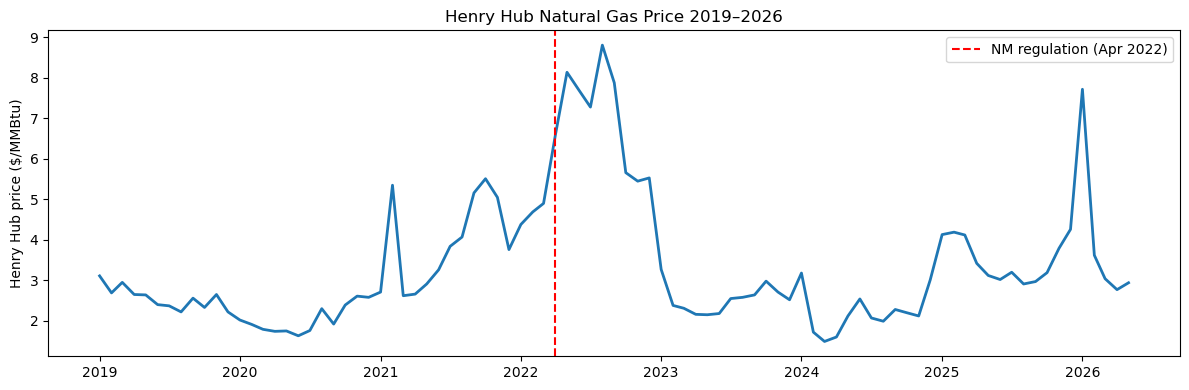

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

henry = pd.read_csv("data/raw/waha_price/henry_hub_monthly.csv", parse_dates=["date"])

print(henry.describe())
print(f"\nAny missing values: {henry.isnull().sum()}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(henry.date, henry.henry_hub_price_per_mmbtu, linewidth=2)
ax.axvline(pd.Timestamp("2022-04-01"), color="red", linestyle="--", label="NM regulation (Apr 2022)")
ax.set_ylabel("Henry Hub price ($/MMBtu)")
ax.set_title("Henry Hub Natural Gas Price 2019–2026")
ax.legend()
plt.tight_layout()
plt.show()

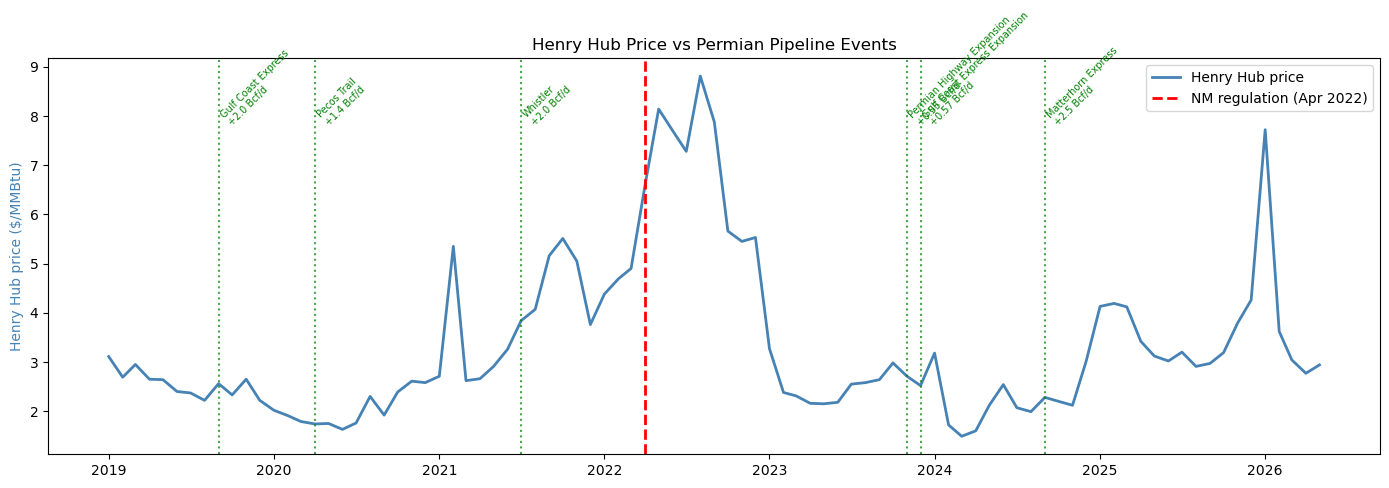

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

henry = pd.read_csv("data/raw/waha_price/henry_hub_monthly.csv", parse_dates=["date"])

# Known Permian pipeline events
pipelines = [
    ("Gulf Coast Express", "2019-09-01", 2.0),
    ("Pecos Trail", "2020-04-01", 1.4),
    ("Whistler", "2021-07-01", 2.0),
    ("Permian Highway Expansion", "2023-11-01", 0.55),
    ("Gulf Coast Express Expansion", "2023-12-01", 0.57),
    ("Matterhorn Express", "2024-09-01", 2.5),
]

fig, ax1 = plt.subplots(figsize=(14, 5))

# Henry Hub price
ax1.plot(henry.date, henry.henry_hub_price_per_mmbtu, 
         color="steelblue", linewidth=2, label="Henry Hub price")
ax1.set_ylabel("Henry Hub price ($/MMBtu)", color="steelblue")
ax1.axvline(pd.Timestamp("2022-04-01"), color="red", 
            linestyle="--", linewidth=2, label="NM regulation (Apr 2022)")

# Pipeline events as vertical markers
for name, date, cap in pipelines:
    ax1.axvline(pd.Timestamp(date), color="green", 
                linestyle=":", alpha=0.7)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1] * 0.85, 
             f"{name}\n+{cap} Bcf/d", fontsize=7, 
             rotation=45, color="green")

ax1.legend()
ax1.set_title("Henry Hub Price vs Permian Pipeline Events")
plt.tight_layout()
plt.show()

In [9]:
import json
import pandas as pd
from pathlib import Path

# Search for Permian gas production series
results = []

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if "permian" in line.lower() and "production" in line.lower():
            try:
                series = json.loads(line)
                print(series["series_id"], "|", series["name"])
                results.append(series)
            except:
                pass

print(f"\nTotal found: {len(results)}")


Total found: 0


In [10]:
import json

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if "new mexico" in line.lower() and "gas" in line.lower() and "produc" in line.lower():
            try:
                series = json.loads(line)
                print(series["series_id"], "|", series["name"])
            except:
                pass

NG.N9050NM2.M | New Mexico Natural Gas Marketed Production, Monthly
NG.N9050NM2.A | New Mexico Natural Gas Marketed Production, Annual
NG.NA1160_SNM_2.A | New Mexico Dry Natural Gas Production, Annual
NG.NA1160_SNM_2.M | New Mexico Dry Natural Gas Production, Monthly
NG.NA1150_SNM_2.M | New Mexico Natural Gas Plant Liquids Production, Monthly
NG.NGM_EPG0_VG9_SNM-SCO_MMCF.A | New Mexico Natural Gas Plant Liquids Production Extracted in Colorado, Annual
NG.NGM_EPG0_VG9_SNM-SNM_MMCF.A | New Mexico Natural Gas Plant Liquids Production Extracted in New Mexico, Annual
NG.NGM_EPG0_VG9_SNM-STX_MMCF.A | New Mexico Natural Gas Plant Liquids Production Extracted in Texas, Annual
NG.NA1150_SNM_2.A | New Mexico Natural Gas Plant Liquids Production, Annual
NG.NGM_EPG0_VG9_SCO-SNM_MMCF.A | Colorado Natural Gas Plant Liquids Production Extracted in New Mexico, Annual
NG.NGM_EPG0_VG9_RTXO-SNM_MMCF.A | Texas Onshore Natural Gas Plant Liquids Production Extracted in New Mexico, Annual
NG.RNGR9910SNM_1.A 

In [11]:
import json

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if "texas" in line.lower() and "marketed production" in line.lower() and ".M" in line:
            try:
                series = json.loads(line)
                print(series["series_id"], "|", series["name"])
            except:
                pass

NG.N9050TX2.M | Texas Natural Gas Marketed Production, Monthly


In [12]:
import json

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if '"NG.N9050NM2.M"' in line:
            series = json.loads(line)
            print(series.keys())
            break

dict_keys(['series_id', 'name', 'units', 'f', 'unitsshort', 'description', 'copyright', 'source', 'iso3166', 'geography', 'start', 'end', 'last_updated', 'data'])


In [13]:
import json

with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        if '"NG.N9050NM2.M"' in line:
            series = json.loads(line)
            print(type(series["data"]))
            print(series["data"][:5])
            break

<class 'list'>
[['202603', 372493], ['202602', 341876], ['202601', 359890], ['202512', 372585], ['202511', 359085]]


In [14]:
import json
import pandas as pd
from pathlib import Path

Path("data/raw/gas_production").mkdir(parents=True, exist_ok=True)

target_series = {
    "NG.N9050NM2.M": "nm_marketed_production_mmcf",
    "NG.N9050TX2.M": "tx_marketed_production_mmcf",
}

# Load all matching series first
found = {}
with open("data/raw/eia_ng_bulk.txt", "r") as f:
    for line in f:
        for series_id in target_series:
            if f'"{series_id}"' in line:
                try:
                    series = json.loads(line)
                    if "data" in series:
                        found[series_id] = series
                except:
                    pass

# Now process
for series_id, col_name in target_series.items():
    if series_id not in found:
        print(f"NOT FOUND: {series_id}")
        continue
    series = found[series_id]
    df = pd.DataFrame(series["data"], columns=["date", col_name])
    df["date"] = pd.to_datetime(df["date"], format="%Y%m")
    df = df.sort_values("date")
    df = df[df["date"] >= "2019-01-01"].reset_index(drop=True)
    print(f"\n{series_id}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(df.head(5))
    df.to_csv(f"data/raw/gas_production/{col_name}.csv", index=False)
    print("Saved.")


NG.N9050NM2.M
Shape: (87, 2)
Date range: 2019-01-01 00:00:00 to 2026-03-01 00:00:00
        date  nm_marketed_production_mmcf
0 2019-01-01                       137940
1 2019-02-01                       128351
2 2019-03-01                       144805
3 2019-04-01                       142454
4 2019-05-01                       147013
Saved.

NG.N9050TX2.M
Shape: (87, 2)
Date range: 2019-01-01 00:00:00 to 2026-03-01 00:00:00
        date  tx_marketed_production_mmcf
0 2019-01-01                       737375
1 2019-02-01                       678066
2 2019-03-01                       758646
3 2019-04-01                       727527
4 2019-05-01                       781002
Saved.


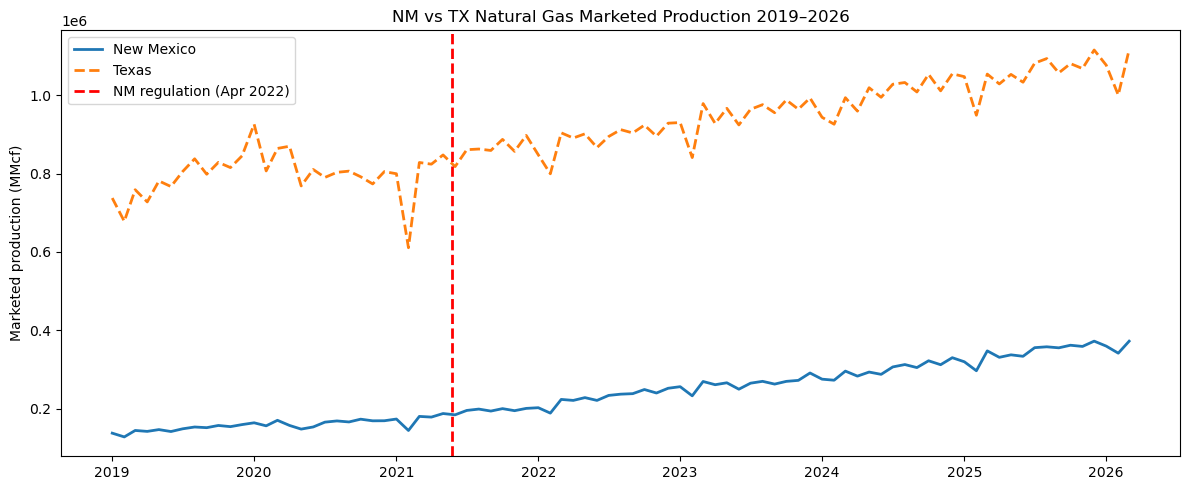

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

nm = pd.read_csv("data/raw/gas_production/nm_marketed_production_mmcf.csv", parse_dates=["date"])
tx = pd.read_csv("data/raw/gas_production/tx_marketed_production_mmcf.csv", parse_dates=["date"])

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(nm.date, nm.nm_marketed_production_mmcf, label="New Mexico", linewidth=2)
ax.plot(tx.date, tx.tx_marketed_production_mmcf , label="Texas ", linewidth=2, linestyle="--")
ax.axvline(pd.Timestamp("2021-05-25"), color="red", linestyle="--", linewidth=2, label="NM regulation (Apr 2022)")

ax.set_ylabel("Marketed production (MMcf)")
ax.set_title("NM vs TX Natural Gas Marketed Production 2019–2026")
ax.legend()
plt.tight_layout()
plt.show()

Lets just take a look at the data to find out what is this sudden dip in texas production around 2021

In [17]:
condition = (nm.date >= "2021-01-01") & (nm.date <= "2021-12-31"  )
tx.loc[condition]

,date,tx_marketed_production_mmcf
24,2021-01-01,799384
25,2021-02-01,610705
26,2021-03-01,828055
27,2021-04-01,823807
28,2021-05-01,847314
29,2021-06-01,817582
30,2021-07-01,860680
31,2021-08-01,862398
32,2021-09-01,858752
33,2021-10-01,886988


In [18]:
nm.loc[condition]

,date,nm_marketed_production_mmcf
24,2021-01-01,173924
25,2021-02-01,144784
26,2021-03-01,180642
27,2021-04-01,178897
28,2021-05-01,187958
29,2021-06-01,184699
30,2021-07-01,195871
31,2021-08-01,199330
32,2021-09-01,194265
33,2021-10-01,200454


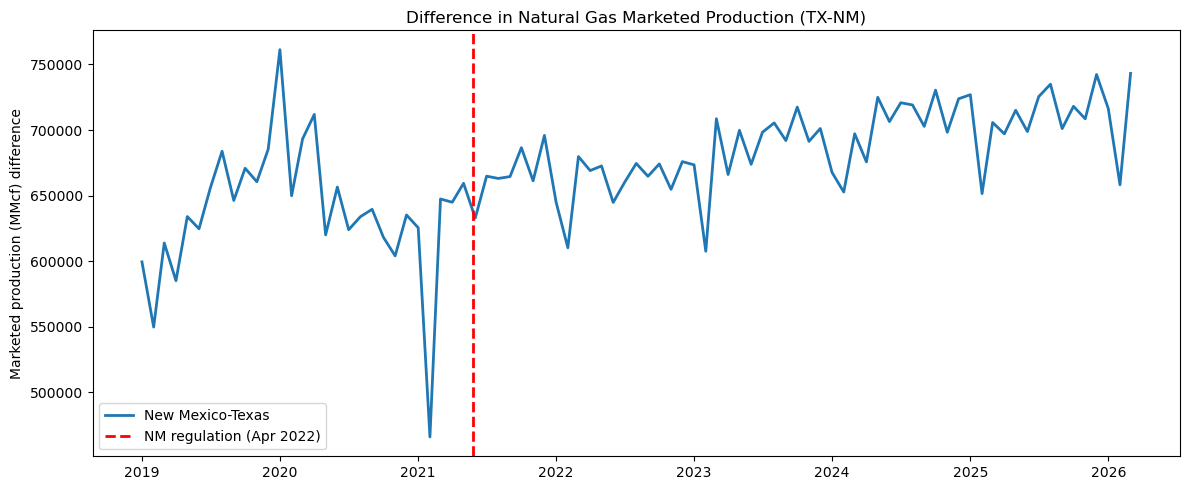

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(nm.date, -nm.nm_marketed_production_mmcf+tx.tx_marketed_production_mmcf, label="New Mexico-Texas", linewidth=2)
ax.axvline(pd.Timestamp("2021-05-25"), color="red", linestyle="--", linewidth=2, label="NM regulation (Apr 2022)")

ax.set_ylabel("Marketed production (MMcf) difference")
ax.set_title("Difference in Natural Gas Marketed Production (TX-NM)")
ax.legend()
plt.tight_layout()
plt.show()

Let is do a simple linear regression on this to see if the average slop is increasing and if so by how much

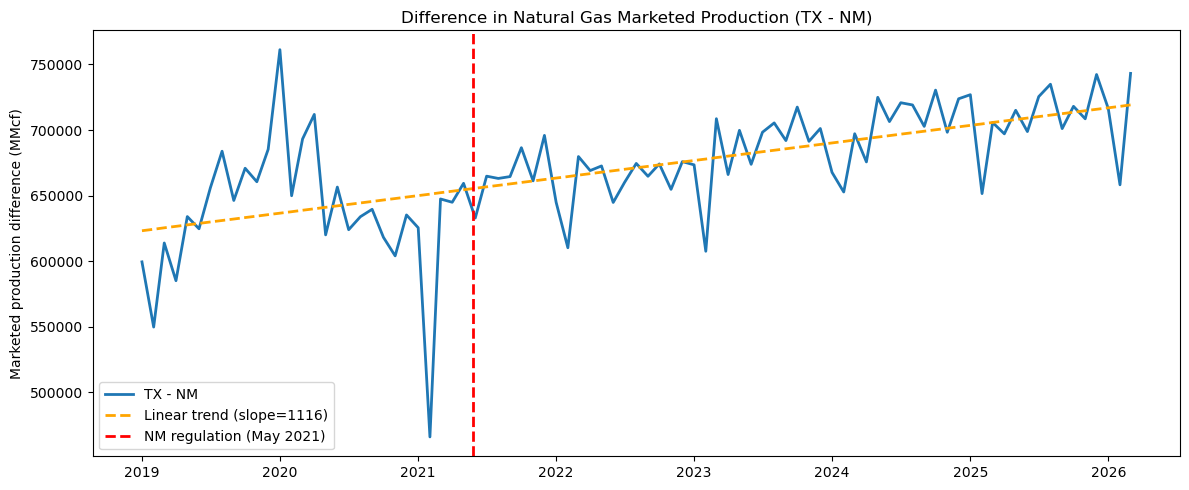

In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
x = np.arange(len(nm)).reshape(-1, 1)
y = (tx.tx_marketed_production_mmcf - nm.nm_marketed_production_mmcf).values

# Fit
lr = LinearRegression()
lr.fit(x, y)
trend = lr.predict(x)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(nm.date, y, label="TX - NM", linewidth=2)
ax.plot(nm.date, trend, color="orange", linestyle="--", 
        linewidth=2, label=f"Linear trend (slope={lr.coef_[0]:.0f})")
ax.axvline(pd.Timestamp("2021-05-25"), color="red", linestyle="--", 
           linewidth=2, label="NM regulation (May 2021)")

ax.set_ylabel("Marketed production difference (MMcf)")
ax.set_title("Difference in Natural Gas Marketed Production (TX - NM)")
ax.legend()
plt.tight_layout()
plt.show()